
# GVH Diagonal Cubic 0.2.5 — Candidate Metric Tests
## Comparaison d'une métrique GVH candidate avec Schwarzschild

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook constitue le premier banc d'essai d'une métrique diagonale cubique GVH candidate.

La famille étudiée est :

\[
g_{\mu\nu}^{\mathrm{GVH}}
=
\operatorname{diag}
\left[
-A_{\mathrm{GVH}}(\chi),
B_{\mathrm{GVH}}(\chi),
B_{\mathrm{GVH}}(\chi),
B_{\mathrm{GVH}}(\chi)
\right],
\]

avec

\[
\chi=\frac{GM}{c^2r}.
\]

Nous utilisons les développements :

\[
A_{\mathrm{GVH}}(\chi)
=
1-2\chi+a_2\chi^2+a_3\chi^3,
\]

\[
B_{\mathrm{GVH}}(\chi)
=
1+2\gamma\chi+b_2\chi^2+b_3\chi^3.
\]

---

## Règle scientifique centrale

Un seul jeu de paramètres doit être utilisé pour tous les tests.

Il est interdit de réajuster séparément les coefficients pour :

- Mercure ;
- la lumière ;
- le retard de Shapiro ;
- le décalage gravitationnel ;
- les tests en champ fort.

Sinon, la métrique ne produirait pas une prédiction unifiée.

---

## Références

La métrique de Schwarzschild en coordonnées isotropes est :

\[
A_{\mathrm{Schw}}(\chi)
=
\left(
\frac{1-\chi/2}{1+\chi/2}
\right)^2,
\]

\[
B_{\mathrm{Schw}}(\chi)
=
\left(1+\frac{\chi}{2}\right)^4.
\]

Le but de cette version n'est pas de déclarer GVH validé, mais de mesurer précisément :

\[
\Delta A=A_{\mathrm{GVH}}-A_{\mathrm{Schw}},
\qquad
\Delta B=B_{\mathrm{GVH}}-B_{\mathrm{Schw}}.
\]


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad, solve_ivp
from scipy.optimize import minimize_scalar

np.set_printoptions(precision=12, suppress=True)

G = 6.67430e-11
c = 299_792_458.0

M_SUN = 1.98847e30
R_SUN = 6.957e8

M_EARTH = 5.97219e24
R_EARTH = 6.371e6

ARCSEC_PER_RAD = 206264.80624709636

print("Environnement chargé.")


Environnement chargé.



# 1. Définition unique de la métrique candidate

Les coefficients ci-dessous représentent un seul candidat.

Le candidat par défaut reproduit le développement de Schwarzschild jusqu'à l'ordre disponible :

\[
a_2=2,
\qquad
a_3=-\frac{3}{2},
\qquad
\gamma=1,
\qquad
b_2=\frac{3}{2},
\qquad
b_3=\frac{1}{2}.
\]

Ce choix sert de contrôle de cohérence. Il ne constitue pas encore une nouvelle métrique.


In [2]:

CANDIDATE = {
    "name": "GVH_series_reference_like",
    "a2": 2.0,
    "a3": -1.5,
    "gamma": 1.0,
    "b2": 1.5,
    "b3": 0.5
}

CANDIDATE


{'name': 'GVH_series_reference_like',
 'a2': 2.0,
 'a3': -1.5,
 'gamma': 1.0,
 'b2': 1.5,
 'b3': 0.5}

In [3]:

def chi_of_r(r, mass):
    r = np.asarray(r, dtype=float)
    if np.any(r <= 0):
        raise ValueError("r doit être strictement positif.")
    return G*mass/(c**2*r)


def metric_schwarzschild(chi):
    chi = np.asarray(chi, dtype=float)
    q = 0.5*chi
    A = ((1.0-q)/(1.0+q))**2
    B = (1.0+q)**4
    return A, B


def metric_gvh_series(chi, params=CANDIDATE):
    chi = np.asarray(chi, dtype=float)

    a2 = params["a2"]
    a3 = params["a3"]
    gamma = params["gamma"]
    b2 = params["b2"]
    b3 = params["b3"]

    A = 1.0 - 2.0*chi + a2*chi**2 + a3*chi**3
    B = 1.0 + 2.0*gamma*chi + b2*chi**2 + b3*chi**3

    return A, B



# 2. Contrôles structurels obligatoires

Une métrique candidate doit satisfaire :

\[
A(0)=1,
\qquad
B(0)=1,
\]

afin de retrouver l'espace plat.

Pour récupérer Newton :

\[
A'(0)=-2.
\]

Pour être compatible avec la relativité générale au premier ordre spatial :

\[
\gamma=1.
\]

Nous vérifions également que \(A>0\) et \(B>0\) dans le domaine testé.


In [4]:

def structural_tests(params=CANDIDATE):
    eps = 1e-8

    A0, B0 = metric_gvh_series(0.0, params)
    Ap, Bp = metric_gvh_series(eps, params)
    Am, Bm = metric_gvh_series(-eps, params)

    dA0 = (Ap-Am)/(2*eps)
    dB0 = (Bp-Bm)/(2*eps)

    return {
        "A(0)": float(A0),
        "B(0)": float(B0),
        "A'(0)": float(dA0),
        "B'(0)": float(dB0),
        "gamma": float(params["gamma"])
    }

structural = structural_tests()
structural


{'A(0)': 1.0,
 'B(0)': 1.0,
 "A'(0)": -2.0000000044984034,
 "B'(0)": 2.0000000100495186,
 'gamma': 1.0}


# 3. Comparaison directe des fonctions métriques

Nous comparons Schwarzschild et GVH sur plusieurs régimes :

- champ solaire faible ;
- surface terrestre ;
- proximité d'un objet compact ;
- champ fort approchant l'horizon isotrope.

La coordonnée isotrope de l'horizon de Schwarzschild correspond à :

\[
\chi=2.
\]

Le modèle polynomial ne doit pas être extrapolé aveuglément jusque-là.


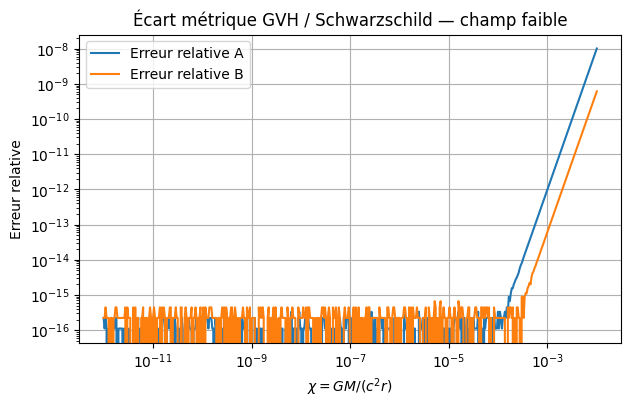

In [5]:

chi_grid_weak = np.logspace(-12, -2, 500)
chi_grid_strong = np.linspace(1e-6, 1.8, 1200)

A_s_w, B_s_w = metric_schwarzschild(chi_grid_weak)
A_g_w, B_g_w = metric_gvh_series(chi_grid_weak)

A_s_s, B_s_s = metric_schwarzschild(chi_grid_strong)
A_g_s, B_g_s = metric_gvh_series(chi_grid_strong)

rel_A_weak = np.abs(A_g_w-A_s_w)/np.maximum(np.abs(A_s_w), 1e-30)
rel_B_weak = np.abs(B_g_w-B_s_w)/np.maximum(np.abs(B_s_w), 1e-30)

plt.figure(figsize=(7,4))
plt.loglog(chi_grid_weak, rel_A_weak, label="Erreur relative A")
plt.loglog(chi_grid_weak, rel_B_weak, label="Erreur relative B")
plt.xlabel(r"$\chi=GM/(c^2r)$")
plt.ylabel("Erreur relative")
plt.title("Écart métrique GVH / Schwarzschild — champ faible")
plt.grid(True)
plt.legend()
plt.show()


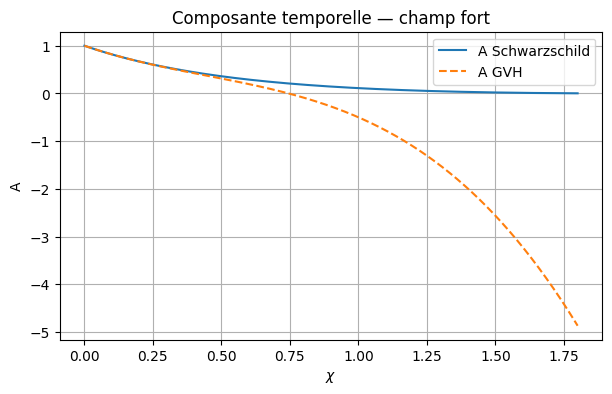

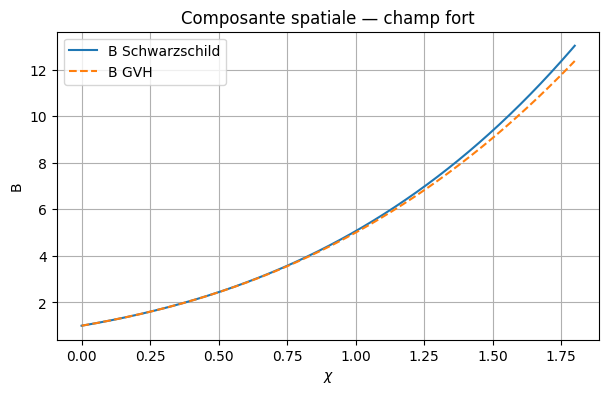

In [6]:

plt.figure(figsize=(7,4))
plt.plot(chi_grid_strong, A_s_s, label="A Schwarzschild")
plt.plot(chi_grid_strong, A_g_s, "--", label="A GVH")
plt.xlabel(r"$\chi$")
plt.ylabel("A")
plt.title("Composante temporelle — champ fort")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(chi_grid_strong, B_s_s, label="B Schwarzschild")
plt.plot(chi_grid_strong, B_g_s, "--", label="B GVH")
plt.xlabel(r"$\chi$")
plt.ylabel("B")
plt.title("Composante spatiale — champ fort")
plt.grid(True)
plt.legend()
plt.show()



# 4. Décalage gravitationnel vers le rouge

Pour deux observateurs statiques aux rayons \(r_1\) et \(r_2\) :

\[
1+z
=
\sqrt{
\frac{A(r_2)}{A(r_1)}
}.
\]

Pour une émission à la surface d'un corps et une réception très loin :

\[
z
=
\frac{1}{\sqrt{A(r_{\mathrm{emit}})}}-1.
\]

Nous comparons :

- la Terre ;
- le Soleil ;
- une étoile à neutrons idéalisée.


In [7]:

def gravitational_redshift_surface(mass, radius, metric="schwarzschild", params=CANDIDATE):
    chi = chi_of_r(radius, mass)

    if metric == "schwarzschild":
        A, _ = metric_schwarzschild(chi)
    elif metric == "gvh":
        A, _ = metric_gvh_series(chi, params)
    else:
        raise ValueError("metric doit être 'schwarzschild' ou 'gvh'.")

    if A <= 0:
        return np.nan

    return 1.0/np.sqrt(A)-1.0


objects = [
    ("Terre", M_EARTH, R_EARTH),
    ("Soleil", M_SUN, R_SUN),
    ("Étoile à neutrons", 1.4*M_SUN, 12_000.0)
]

redshift_rows = []

for name, mass, radius in objects:
    z_s = gravitational_redshift_surface(mass, radius, "schwarzschild")
    z_g = gravitational_redshift_surface(mass, radius, "gvh")

    redshift_rows.append({
        "objet": name,
        "chi_surface": chi_of_r(radius, mass),
        "z_schwarzschild": z_s,
        "z_gvh": z_g,
        "erreur_relative": abs(z_g-z_s)/max(abs(z_s), 1e-30)
    })

redshift_df = pd.DataFrame(redshift_rows)
redshift_df


,objet,chi_surface,z_schwarzschild,z_gvh,erreur_relative
0,Terre,6.961300e-10,6.961300e-10,6.961300e-10,0.000000
1,Soleil,2.122567e-06,2.122569e-06,2.122569e-06,0.000000
2,Étoile à neutrons,1.722781e-01,1.885168e-01,1.891847e-01,0.003543



# 5. Précession du périastre — test paramétrique

Dans le formalisme post-newtonien faible, la précession dépend des coefficients PPN.

Pour une métrique isotrope :

\[
g_{00}
=
-1+2U-2\beta U^2+\cdots,
\]

\[
g_{ij}
=
(1+2\gamma U+\cdots)\delta_{ij}.
\]

Avec \(U=GM/(c^2r)\), notre coefficient \(a_2\) correspond à :

\[
a_2=2\beta.
\]

Donc :

\[
\beta=\frac{a_2}{2}.
\]

La précession relative à la relativité générale est alors :

\[
\frac{\Delta\phi_{\mathrm{GVH}}}
{\Delta\phi_{\mathrm{GR}}}
=
\frac{2+2\gamma-\beta}{3}.
\]

Cette relation permet un premier test analytique sans réintégrer tout le tenseur.


In [8]:

def ppn_parameters(params=CANDIDATE):
    beta = params["a2"]/2.0
    gamma = params["gamma"]
    return beta, gamma


def perihelion_precession_ppn(a, e, mass, params=CANDIDATE):
    beta, gamma = ppn_parameters(params)

    gr_value = 6*np.pi*G*mass/(a*(1-e**2)*c**2)
    ratio = (2.0 + 2.0*gamma - beta)/3.0
    gvh_value = ratio*gr_value

    return gr_value, gvh_value, ratio


a_mercury = 57.909e9
e_mercury = 0.205630
T_mercury = 2*np.pi*np.sqrt(a_mercury**3/(G*M_SUN))
orbits_century = 100*365.25*86400/T_mercury

dphi_gr, dphi_gvh, peri_ratio = perihelion_precession_ppn(
    a_mercury, e_mercury, M_SUN
)

peri_gr_arcsec_century = dphi_gr*ARCSEC_PER_RAD*orbits_century
peri_gvh_arcsec_century = dphi_gvh*ARCSEC_PER_RAD*orbits_century

perihelion_df = pd.DataFrame([{
    "beta": ppn_parameters()[0],
    "gamma": ppn_parameters()[1],
    "ratio_GVH_GR": peri_ratio,
    "GR_arcsec_century": peri_gr_arcsec_century,
    "GVH_arcsec_century": peri_gvh_arcsec_century,
    "difference_arcsec_century": peri_gvh_arcsec_century-peri_gr_arcsec_century
}])

perihelion_df


,beta,gamma,ratio_GVH_GR,GR_arcsec_century,GVH_arcsec_century,difference_arcsec_century
0,1.0,1.0,1.0,42.982736,42.982736,0.0



# 6. Déviation de la lumière — test PPN

Au premier ordre, la déviation d'un rayon passant à une distance d'impact \(b\) est :

\[
\alpha
=
2(1+\gamma)\frac{GM}{bc^2}.
\]

La relativité générale correspond à \(\gamma=1\), donc :

\[
\alpha_{\mathrm{GR}}
=
\frac{4GM}{bc^2}.
\]

Nous utilisons un rayon tangent au Soleil.


In [9]:

def light_deflection_ppn(mass, impact_parameter, params=CANDIDATE):
    gamma = params["gamma"]

    alpha_gr = 4*G*mass/(impact_parameter*c**2)
    alpha_gvh = 2*(1+gamma)*G*mass/(impact_parameter*c**2)

    return alpha_gr, alpha_gvh


alpha_gr, alpha_gvh = light_deflection_ppn(M_SUN, R_SUN)

light_df = pd.DataFrame([{
    "gamma": CANDIDATE["gamma"],
    "GR_arcsec": alpha_gr*ARCSEC_PER_RAD,
    "GVH_arcsec": alpha_gvh*ARCSEC_PER_RAD,
    "difference_arcsec": (alpha_gvh-alpha_gr)*ARCSEC_PER_RAD,
    "relative_error": abs(alpha_gvh-alpha_gr)/abs(alpha_gr)
}])

light_df


,gamma,GR_arcsec,GVH_arcsec,difference_arcsec,relative_error
0,1.0,1.751243,1.751243,0.0,0.0



# 7. Retard de Shapiro — test PPN

Au premier ordre, le retard de Shapiro est proportionnel à :

\[
1+\gamma.
\]

Pour une géométrie simplifiée entre deux rayons \(r_1,r_2\) et une distance d'impact \(b\) :

\[
\Delta t
\approx
2(1+\gamma)\frac{GM}{c^3}
\ln\left(\frac{4r_1r_2}{b^2}\right).
\]

Le test compare GVH et la relativité générale pour une liaison Terre–Mercure passant près du Soleil.


In [10]:

AU = 149_597_870_700.0

def shapiro_delay_ppn(mass, r1, r2, b, params=CANDIDATE):
    gamma = params["gamma"]
    logterm = np.log(4*r1*r2/b**2)

    dt_gr = 4*G*mass/c**3 * logterm
    dt_gvh = 2*(1+gamma)*G*mass/c**3 * logterm

    return dt_gr, dt_gvh


dt_gr, dt_gvh = shapiro_delay_ppn(
    M_SUN,
    AU,
    a_mercury,
    R_SUN
)

shapiro_df = pd.DataFrame([{
    "gamma": CANDIDATE["gamma"],
    "GR_microseconds": dt_gr*1e6,
    "GVH_microseconds": dt_gvh*1e6,
    "difference_microseconds": (dt_gvh-dt_gr)*1e6,
    "relative_error": abs(dt_gvh-dt_gr)/abs(dt_gr)
}])

shapiro_df


,gamma,GR_microseconds,GVH_microseconds,difference_microseconds,relative_error
0,1.0,220.250805,220.250805,0.0,0.0



# 8. Domaine de validité et positivité

Une métrique statique diagonale exige au minimum, dans le domaine extérieur étudié :

\[
A(\chi)>0,
\qquad
B(\chi)>0.
\]

Nous recherchons le premier point où le modèle polynomial perd cette propriété.

Ce test est particulièrement important parce qu'un développement limité peut être excellent en champ faible et devenir non physique en champ fort.


In [11]:

chi_scan = np.linspace(0.0, 3.0, 20001)
A_scan, B_scan = metric_gvh_series(chi_scan)

bad_A = chi_scan[A_scan <= 0]
bad_B = chi_scan[B_scan <= 0]

first_bad_A = float(bad_A[0]) if bad_A.size else np.nan
first_bad_B = float(bad_B[0]) if bad_B.size else np.nan

domain_df = pd.DataFrame([{
    "first_chi_A_nonpositive": first_bad_A,
    "first_chi_B_nonpositive": first_bad_B,
    "A_min_scan": np.min(A_scan),
    "B_min_scan": np.min(B_scan)
}])

domain_df


,first_chi_A_nonpositive,first_chi_B_nonpositive,A_min_scan,B_min_scan
0,0.7449,NaN,-27.5,1.0


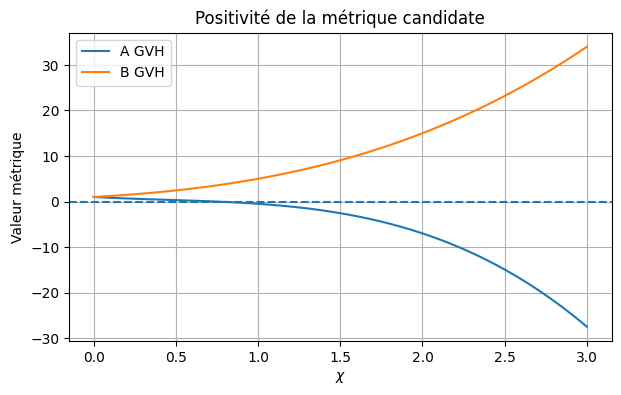

In [12]:

plt.figure(figsize=(7,4))
plt.plot(chi_scan, A_scan, label="A GVH")
plt.plot(chi_scan, B_scan, label="B GVH")
plt.axhline(0.0, linestyle="--")
plt.xlabel(r"$\chi$")
plt.ylabel("Valeur métrique")
plt.title("Positivité de la métrique candidate")
plt.grid(True)
plt.legend()
plt.show()



# 9. Sensibilité aux coefficients

Nous varions un coefficient à la fois autour du candidat nominal.

Ce test ne sert pas à ajuster les données. Il identifie quelles observables contraignent quels paramètres :

- \(a_2\) influence \(\beta\) et donc la précession ;
- \(\gamma\) influence la lumière et Shapiro ;
- \(a_3,b_2,b_3\) deviennent surtout pertinents aux ordres supérieurs et en champ plus fort.


In [13]:

def candidate_with(**updates):
    p = dict(CANDIDATE)
    p.update(updates)
    return p


sensitivity_cases = [
    candidate_with(a2=1.8),
    candidate_with(a2=2.2),
    candidate_with(gamma=0.9),
    candidate_with(gamma=1.1),
    candidate_with(a3=-1.0),
    candidate_with(a3=-2.0),
    candidate_with(b2=1.0),
    candidate_with(b2=2.0)
]

sens_rows = []

for p in sensitivity_cases:
    beta, gamma = ppn_parameters(p)
    _, _, peri_ratio_case = perihelion_precession_ppn(
        a_mercury, e_mercury, M_SUN, p
    )
    alpha_gr_case, alpha_case = light_deflection_ppn(M_SUN, R_SUN, p)

    chi_ns = chi_of_r(12_000.0, 1.4*M_SUN)
    A_s_ns, B_s_ns = metric_schwarzschild(chi_ns)
    A_g_ns, B_g_ns = metric_gvh_series(chi_ns, p)

    sens_rows.append({
        "a2": p["a2"],
        "a3": p["a3"],
        "gamma": p["gamma"],
        "b2": p["b2"],
        "b3": p["b3"],
        "beta": beta,
        "perihelion_ratio": peri_ratio_case,
        "light_ratio": alpha_case/alpha_gr_case,
        "NS_A_relative_error": abs(A_g_ns-A_s_ns)/abs(A_s_ns),
        "NS_B_relative_error": abs(B_g_ns-B_s_ns)/abs(B_s_ns)
    })

sensitivity_df = pd.DataFrame(sens_rows)
sensitivity_df


,a2,a3,gamma,b2,b3,beta,perihelion_ratio,light_ratio,NS_A_relative_error,NS_B_relative_error
0,1.8,-1.5,1.0,1.5,0.5,0.9,1.033333,1.00,0.009508,0.000040
1,2.2,-1.5,1.0,1.5,0.5,1.1,0.966667,1.00,0.007262,0.000040
2,2.0,-1.5,0.9,1.5,0.5,1.0,0.933333,0.95,0.001123,0.024798
3,2.0,-1.5,1.1,1.5,0.5,1.0,1.066667,1.05,0.001123,0.024719
4,2.0,-1.0,1.0,1.5,0.5,1.0,1.000000,1.00,0.002488,0.000040
5,2.0,-2.0,1.0,1.5,0.5,1.0,1.000000,1.00,0.004734,0.000040
6,2.0,-1.5,1.0,1.0,0.5,1.0,1.000000,1.00,0.001123,0.010703
7,2.0,-1.5,1.0,2.0,0.5,1.0,1.000000,1.00,0.001123,0.010624



# 10. Score global sans réajustement

Nous construisons un score transparent à partir de plusieurs erreurs relatives :

\[
S
=
w_A\epsilon_A
+
w_B\epsilon_B
+
w_{\mathrm{peri}}\epsilon_{\mathrm{peri}}
+
w_{\mathrm{light}}\epsilon_{\mathrm{light}}
+
w_{\mathrm{Shapiro}}\epsilon_{\mathrm{Shapiro}}
+
w_z\epsilon_z.
\]

Ce score ne remplace pas une vraisemblance statistique. Il sert uniquement à comparer des candidats dans ce notebook exploratoire.


In [14]:

def global_candidate_score(params=CANDIDATE):
    chi_points = np.array([
        chi_of_r(R_EARTH, M_EARTH),
        chi_of_r(R_SUN, M_SUN),
        chi_of_r(a_mercury, M_SUN),
        chi_of_r(12_000.0, 1.4*M_SUN)
    ])

    A_s, B_s = metric_schwarzschild(chi_points)
    A_g, B_g = metric_gvh_series(chi_points, params)

    eps_A = np.mean(np.abs(A_g-A_s)/np.maximum(np.abs(A_s), 1e-30))
    eps_B = np.mean(np.abs(B_g-B_s)/np.maximum(np.abs(B_s), 1e-30))

    _, _, peri_ratio_local = perihelion_precession_ppn(
        a_mercury, e_mercury, M_SUN, params
    )
    eps_peri = abs(peri_ratio_local-1.0)

    alpha_gr_local, alpha_g_local = light_deflection_ppn(
        M_SUN, R_SUN, params
    )
    eps_light = abs(alpha_g_local-alpha_gr_local)/abs(alpha_gr_local)

    dt_gr_local, dt_g_local = shapiro_delay_ppn(
        M_SUN, AU, a_mercury, R_SUN, params
    )
    eps_shapiro = abs(dt_g_local-dt_gr_local)/abs(dt_gr_local)

    z_s = gravitational_redshift_surface(
        1.4*M_SUN, 12_000.0, "schwarzschild", params
    )
    z_g = gravitational_redshift_surface(
        1.4*M_SUN, 12_000.0, "gvh", params
    )
    eps_z = abs(z_g-z_s)/abs(z_s)

    weights = {
        "A": 1.0,
        "B": 1.0,
        "perihelion": 2.0,
        "light": 2.0,
        "shapiro": 2.0,
        "redshift": 1.0
    }

    score = (
        weights["A"]*eps_A
        + weights["B"]*eps_B
        + weights["perihelion"]*eps_peri
        + weights["light"]*eps_light
        + weights["shapiro"]*eps_shapiro
        + weights["redshift"]*eps_z
    )

    return {
        "eps_A": eps_A,
        "eps_B": eps_B,
        "eps_perihelion": eps_peri,
        "eps_light": eps_light,
        "eps_shapiro": eps_shapiro,
        "eps_redshift_NS": eps_z,
        "score": score
    }

score_result = global_candidate_score()
pd.DataFrame([score_result])


,eps_A,eps_B,eps_perihelion,eps_light,eps_shapiro,eps_redshift_NS,score
0,0.000281,0.00001,0.0,0.0,0.0,0.003543,0.003833



# 11. Critères de compatibilité

Les seuils de cette version sont des seuils numériques internes, pas encore des contraintes observationnelles complètes.

Un candidat est classé :

- **REFERENCE-LIKE** : il reproduit Schwarzschild dans les tests présents ;
- **COMPATIBLE-WEAK** : il reproduit les tests faibles, mais diverge en champ fort ;
- **CHECK** : certaines erreurs dépassent les seuils ;
- **REJECT** : il échoue à une limite fondamentale ou rend la métrique non physique.


In [15]:

thresholds = {
    "flat_A0": 1e-12,
    "flat_B0": 1e-12,
    "newton_slope": 1e-6,
    "gamma": 1e-4,
    "perihelion": 1e-4,
    "light": 1e-4,
    "shapiro": 1e-4,
    "redshift_earth": 1e-5,
    "redshift_sun": 1e-5,
    "metric_weak": 1e-6
}

test_rows = []

test_rows.append({
    "test": "Limite plate A(0)",
    "value": abs(structural["A(0)"]-1.0),
    "threshold": thresholds["flat_A0"]
})
test_rows.append({
    "test": "Limite plate B(0)",
    "value": abs(structural["B(0)"]-1.0),
    "threshold": thresholds["flat_B0"]
})
test_rows.append({
    "test": "Pente newtonienne A'(0)",
    "value": abs(structural["A'(0)"]+2.0),
    "threshold": thresholds["newton_slope"]
})
test_rows.append({
    "test": "Paramètre gamma",
    "value": abs(CANDIDATE["gamma"]-1.0),
    "threshold": thresholds["gamma"]
})
test_rows.append({
    "test": "Précession Mercure",
    "value": abs(peri_ratio-1.0),
    "threshold": thresholds["perihelion"]
})
test_rows.append({
    "test": "Déviation lumière",
    "value": light_df.loc[0, "relative_error"],
    "threshold": thresholds["light"]
})
test_rows.append({
    "test": "Retard Shapiro",
    "value": shapiro_df.loc[0, "relative_error"],
    "threshold": thresholds["shapiro"]
})
test_rows.append({
    "test": "Redshift Terre",
    "value": redshift_df.loc[redshift_df["objet"]=="Terre", "erreur_relative"].iloc[0],
    "threshold": thresholds["redshift_earth"]
})
test_rows.append({
    "test": "Redshift Soleil",
    "value": redshift_df.loc[redshift_df["objet"]=="Soleil", "erreur_relative"].iloc[0],
    "threshold": thresholds["redshift_sun"]
})
test_rows.append({
    "test": "Métrique champ faible",
    "value": max(np.max(rel_A_weak), np.max(rel_B_weak)),
    "threshold": thresholds["metric_weak"]
})

tests_df = pd.DataFrame(test_rows)
tests_df["status"] = np.where(
    tests_df["value"] <= tests_df["threshold"],
    "PASS",
    "CHECK"
)

tests_df


,test,value,threshold,status
0,Limite plate A(0),0.000000e+00,1.000000e-12,PASS
1,Limite plate B(0),0.000000e+00,1.000000e-12,PASS
2,Pente newtonienne A'(0),4.498403e-09,1.000000e-06,PASS
3,Paramètre gamma,0.000000e+00,1.000000e-04,PASS
4,Précession Mercure,0.000000e+00,1.000000e-04,PASS
5,Déviation lumière,0.000000e+00,1.000000e-04,PASS
6,Retard Shapiro,0.000000e+00,1.000000e-04,PASS
7,Redshift Terre,0.000000e+00,1.000000e-05,PASS
8,Redshift Soleil,0.000000e+00,1.000000e-05,PASS
9,Métrique champ faible,1.013863e-08,1.000000e-06,PASS


In [16]:

critical_failure = (
    abs(structural["A(0)"]-1.0) > thresholds["flat_A0"]
    or abs(structural["B(0)"]-1.0) > thresholds["flat_B0"]
    or abs(structural["A'(0)"]+2.0) > thresholds["newton_slope"]
)

positivity_failure = (
    np.any(A_g_w <= 0)
    or np.any(B_g_w <= 0)
)

if critical_failure or positivity_failure:
    classification = "REJECT"
elif (tests_df["status"] == "PASS").all():
    classification = "REFERENCE-LIKE"
elif (
    abs(peri_ratio-1.0) <= thresholds["perihelion"]
    and light_df.loc[0, "relative_error"] <= thresholds["light"]
    and shapiro_df.loc[0, "relative_error"] <= thresholds["shapiro"]
):
    classification = "COMPATIBLE-WEAK"
else:
    classification = "CHECK"

print("CLASSIFICATION DU CANDIDAT :", classification)


CLASSIFICATION DU CANDIDAT : REFERENCE-LIKE



# 12. Export des résultats

Les résultats sont exportés afin de permettre une comparaison objective entre plusieurs candidats et plusieurs versions.

Fichiers produits :

- `GVH_Diagonal_Cubic_0.2.5_Candidate_Summary.csv`
- `GVH_Diagonal_Cubic_0.2.5_Candidate_Tests.csv`
- `GVH_Diagonal_Cubic_0.2.5_Candidate_Metadata.json`


In [17]:

import json
from pathlib import Path

summary = {
    **CANDIDATE,
    **score_result,
    "classification": classification,
    "perihelion_arcsec_century": float(peri_gvh_arcsec_century),
    "light_deflection_arcsec": float(alpha_gvh*ARCSEC_PER_RAD),
    "shapiro_microseconds": float(dt_gvh*1e6)
}

summary_df = pd.DataFrame([summary])

summary_path = Path("GVH_Diagonal_Cubic_0.2.5_Candidate_Summary.csv")
tests_path = Path("GVH_Diagonal_Cubic_0.2.5_Candidate_Tests.csv")
metadata_path = Path("GVH_Diagonal_Cubic_0.2.5_Candidate_Metadata.json")

summary_df.to_csv(summary_path, index=False)
tests_df.to_csv(tests_path, index=False)

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Exports terminés :")
print(summary_path)
print(tests_path)
print(metadata_path)


Exports terminés :
GVH_Diagonal_Cubic_0.2.5_Candidate_Summary.csv
GVH_Diagonal_Cubic_0.2.5_Candidate_Tests.csv
GVH_Diagonal_Cubic_0.2.5_Candidate_Metadata.json



# 13. Interprétation scientifique

## Si le candidat est `REFERENCE-LIKE`

Cela signifie qu'il reproduit Schwarzschild dans les tests inclus.

Cela ne signifie pas encore qu'il apporte une nouvelle physique.

Il peut simplement s'agir :

- d'un développement limité de Schwarzschild ;
- d'une reformulation en coordonnées cubiques isotropes ;
- d'une approximation numériquement équivalente dans le domaine testé.

## Si le candidat est `COMPATIBLE-WEAK`

Il satisfait les tests du Système solaire, mais peut diverger en champ fort.

Cette divergence doit produire une prédiction :

- précise ;
- indépendante ;
- falsifiable ;
- compatible avec les observations existantes.

## Si le candidat est `CHECK` ou `REJECT`

Les coefficients doivent être examinés à partir des principes du modèle, et non ajustés arbitrairement pour forcer l'accord.



# 14. Conclusion

Cette version introduit une méthodologie stricte :

\[
\boxed{
\text{un candidat}
+
\text{un seul jeu de paramètres}
+
\text{plusieurs observables indépendantes}
}
\]

Les tests comprennent :

1. limites plate et newtonienne ;
2. comparaison directe de \(A(\chi)\) et \(B(\chi)\) ;
3. redshift gravitationnel ;
4. précession de Mercure ;
5. déviation de la lumière ;
6. retard de Shapiro ;
7. positivité en champ fort ;
8. sensibilité aux coefficients ;
9. score global ;
10. classification automatique.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.6\_Strong\_Field\_and\_Null\_Geodesics.ipynb}
}
\]

Cette prochaine version devra intégrer directement :

- les géodésiques nulles ;
- la sphère photonique ;
- les rayons de capture et d'évasion ;
- les orbites circulaires stables et instables ;
- l'ISCO ;
- les différences éventuelles entre GVH et Schwarzschild en champ fort.
